In [54]:
import math
import numpy as np
import casadi as ca
import sympy as sp
import matplotlib.pyplot as plt
import importlib
import time
import sys
import csv
from pathlib import Path

# -------------------------
# Load k1 polynomials produced by MATLAB (SymPy expressions)
# -------------------------
# try:
# k1mod = importlib.import_module('k1_dubins_car')
from k1_dubins_car_copy import k1_0, k1_1, y, val_lambda, val_delta


In [55]:
# except Exception as e:
#     raise RuntimeError("Failed to import k1_dubins_car.py. Ensure it's in the same folder and defines k1_0,k1_1.") from e

# if not hasattr(k1mod, 'k1_0') or not hasattr(k1mod, 'k1_1'):
#     raise RuntimeError("k1_dubins_car.py must define k1_0 and k1_1 (SymPy expressions in y0,y1).")

# use values but DO NOT simplify
k1_0_sym = k1_0
k1_1_sym = k1_1
lam_val = val_lambda  #float(getattr(k1mod, 'val_lambda', 1e-5))
delta_val = val_delta #float(getattr(k1mod, 'val_delta', 0.0))

print("==== k1 sympy expressions ====")
print("k1_0_sym:", k1_0_sym)
print("k1_1_sym:", k1_1_sym)

# -------------------------
# Parameters / model
# -------------------------
nx = 4
nu = 2
DT = 0.002
HORIZON = 8
MU_1 = 1000
U_MIN = np.array([-10000.0, -10000.0])
U_MAX = np.array([ 10000.0,  10000.0])
EPS_G_INV = 1e-6   # for Tikhonov regularization of G inverse

# weights for MPC cost
Qy = 1.0       # weight for output tracking (scalar)
R_u = 0.01     # control effort weight
ALPHA = 10.0   # weight for ||u - k(x)||^2 (stage)
# ALPHA_TERM = 50.0  # extra weight on terminal stage (optional)

# goal in output space (y)
GOAL = np.array([-1.841, 0])

# solver options
IPOPT_MAX_CPU = 1.5
IPOPT_TOL = 1e-6

# logging file
LOG_CSV = "mpc_upgraded_log.csv"

# -------------------------
# Sympy symbols for conversion
# -------------------------
y0_s, y1_s = sp.symbols('y0 y1')
x0_s, x1_s, x2_s, x3_s = sp.symbols('x0 x1 x2 x3')

# -------------------------
# psi (safe set) and phi (target) as given previously
# psi(y) = a*(R - y2)^2 - b*y1 - (y1^4 + y2^4 - R^2)^2
R_val = 3.5
a_val = 2.0
b_val = 1.5
# psi_sym = a_val * (R_val - y1_s)**2 - b_val * y0_s - (y0_s**4 + y1_s**4 - R_val**2)**2
# phi_sym = (y0_s + 0.5)**2 + ((y1_s + 1.9) / 0.5)**2 - 1

psi_sym = - (y0_s**4 + y1_s**4 - 16) * (y0_s**4 + y1_s**4 - 8)
phi_sym = ((y0_s + 1.841) / 0.5)**2 + (y1_s)**2  - 0.1

# lambdify for diagnostic numeric evaluation (fast)
psi_func_numpy = sp.lambdify((y0_s, y1_s), psi_sym, 'numpy')
phi_func_numpy = sp.lambdify((y0_s, y1_s), phi_sym, 'numpy')


==== k1 sympy expressions ====
k1_0_sym: -0.19714*y0**4 + 3.7662e-17*y0**3*y1 - 1.9504*y0**3 + 0.57221*y0**2*y1**2 + 1.2506e-16*y0**2*y1 - 1.1551*y0**2 + 6.3799e-16*y0*y1**3 - 0.40378*y0*y1**2 - 1.371e-16*y0*y1 + 6.8054*y0 - 24.8899*y1**4 - 2.8172e-17*y1**3 - 2.4721*y1**2 - 4.6193e-16*y1 + 6.4481
k1_1_sym: -3.881e-16*y0**4 + 24.6136*y0**3*y1 + 9.9483e-17*y0**3 + 1.0575e-16*y0**2*y1**2 - 1.3983*y0**2*y1 - 1.011e-15*y0**2 - 0.70475*y0*y1**3 - 1.0488e-16*y0*y1**2 + 2.3469*y0*y1 + 2.0959e-16*y0 + 7.0033e-18*y1**4 - 2.0483*y1**3 - 7.7029e-17*y1**2 + 7.0416*y1 + 5.7487e-16


In [56]:

# -------------------------
# helper: convert sympy polynomial expression to CasADi SX polynomial
# (no simplify, use sp.expand -> sp.Poly to get monomials)
# -------------------------
def sympy_poly_to_casadi_SX(sym_expr, sym_vars=(y0_s, y1_s), cas_vars=None):
    """
    Convert a SymPy polynomial (in sym_vars) to a CasADi SX expression in cas_vars ordering.
    Avoid heavy symbolic simplify operations.
    """
    if cas_vars is None:
        cas_vars = [ca.SX.sym('y0'), ca.SX.sym('y1')]
    poly = sp.Poly(sp.expand(sym_expr), *sym_vars)
    # poly = sp.Poly(sym_expr, *sym_vars)
    expr_val = ca.SX(0)
    for mon_exps, coeff in poly.as_dict().items():
        coeff_f = float(sp.N(coeff))
        term = ca.SX(coeff_f)
        for idx, e in enumerate(mon_exps):
            if e != 0:
                term = term * (cas_vars[idx] ** int(e))
        expr_val = expr_val + term
    return expr_val

# -------------------------
# Build CasADi SX expressions for psi(y), k1(y) (in terms of y), and their CasADi derivatives
# -------------------------
# CasADi symbolic vars
x_c = ca.SX.sym('x', nx)   # full state symbol
u_c = ca.SX.sym('u', nu)
y_c = ca.vertcat(x_c[0], x_c[1])  # y = h(x)

# Build psi_cas in terms of y_c
psi_cas = sympy_poly_to_casadi_SX(psi_sym, (y0_s, y1_s), cas_vars=[y_c[0], y_c[1]])

# Build k1_cas(y) in terms of y components
k1_0_cas = sympy_poly_to_casadi_SX(k1_0_sym, (y0_s, y1_s), cas_vars=[y_c[0], y_c[1]])
print("k1_0_cas:", k1_0_cas)
k1_1_cas = sympy_poly_to_casadi_SX(k1_1_sym, (y0_s, y1_s), cas_vars=[y_c[0], y_c[1]])
print("k1_1_cas:", k1_1_cas)
k1_cas = ca.vertcat(k1_0_cas, k1_1_cas)

# Build Dy_psi as CasADi (gradient of psi wrt y)
dpsi_dy0_cas = ca.jacobian(psi_cas, y_c)[0]  # returns [dpsi/dy0, dpsi/dy1] as row, so use jacobian directly
dpsi_cas = ca.jacobian(psi_cas, y_c).T  # 2x1

# Build Dk1(y) as CasADi (2x2 Jacobian)
Dk1_cas = ca.jacobian(k1_cas, y_c)  # 2x2 matrix (each row derivative wrt y)

# -------------------------
# Build CasADi expressions for Lfh(x), G(x), and k_full(x) (full-state backstepping controller)
# k(x) = G^{-1} [ mu * Dy_psi + Dk1 * Lfh + (lambda/2)*(Lfh - k1) ]
# Use Tikhonov regularization: Ginv = (G^T G + eps I)^{-1} G^T
# -------------------------
# Lfh_cas (2x1)
Lfh_cas = ca.vertcat(x_c[3] * ca.cos(x_c[2]), x_c[3] * ca.sin(x_c[2]))

# G(x) as CasADi SX 2x2
# Derived earlier: G = [[ -v*sinθ, cosθ],
#                       [  v*cosθ, sinθ]]
G11 = -x_c[3] * ca.sin(x_c[2])
G12 = ca.cos(x_c[2])
G21 =  x_c[3] * ca.cos(x_c[2])
G22 = ca.sin(x_c[2])
G_cas = ca.vertcat( ca.horzcat(G11, G12), ca.horzcat(G21, G22) )  # 2x2

# Tikhonov-regularized inverse: Ginv = (G^T G + eps I)^{-1} G^T
eps_reg = EPS_G_INV
GtG = ca.mtimes(G_cas.T, G_cas)
GtG_reg = GtG + eps_reg * ca.SX.eye(2)
GtG_reg_inv = ca.inv(GtG_reg)   # 2x2
Ginv_cas = ca.mtimes(GtG_reg_inv, G_cas.T)

# k1 at x (substitute y = x[0:2]) => since k1_cas uses y_c which equals x_c[0:2], we can use k1_cas directly
k1_at_x_cas = k1_cas  # depends on y_c which is x_c[0:2]

# Dk1 * Lfh (2x1)
Dk1Lfh_cas = ca.mtimes(Dk1_cas, Lfh_cas)

# Dy_psi at x_c
Dy_psi_at_x_cas = dpsi_cas  # depends on y_c which equals x_c[0:2]

# Build RHS and k_full_cas
rhs_k_cas = MU_1 * Dy_psi_at_x_cas + Dk1Lfh_cas + (lam_val/2.0) * (Lfh_cas - k1_at_x_cas)
k_full_cas = ca.mtimes(Ginv_cas, rhs_k_cas)  # 2x1 CasADi SX vector

# Make a CasADi function for k_full for diagnostics if needed
k_full_fun = ca.Function('k_full_fun', [x_c], [k_full_cas], ['x'], ['k'])
k1_fun = ca.Function('k1_fun', [x_c], [k1_cas], ['x'], ['k'])


k1_0_cas: ((((((((((((((6.4481+(-4.6193e-16*x_1))+(-2.4721*sq(x_1)))+(-2.8172e-17*(x_1*sq(x_1))))+(-24.8899*sq(sq(x_1))))+(6.8054*x_0))+((-1.371e-16*x_0)*x_1))+((-0.40378*x_0)*sq(x_1)))+((6.3799e-16*x_0)*(x_1*sq(x_1))))+(-1.1551*sq(x_0)))+((1.2506e-16*sq(x_0))*x_1))+((0.57221*sq(x_0))*sq(x_1)))+(-1.9504*(x_0*sq(x_0))))+((3.7662e-17*(x_0*sq(x_0)))*x_1))+(-0.19714*sq(sq(x_0))))
k1_1_cas: ((((((((((((((5.7487e-16+(7.0416*x_1))+(-7.7029e-17*sq(x_1)))+(-2.0483*(x_1*sq(x_1))))+(7.0033e-18*sq(sq(x_1))))+(2.0959e-16*x_0))+((2.3469*x_0)*x_1))+((-1.0488e-16*x_0)*sq(x_1)))+((-0.70475*x_0)*(x_1*sq(x_1))))+(-1.011e-15*sq(x_0)))+((-1.3983*sq(x_0))*x_1))+((1.0575e-16*sq(x_0))*sq(x_1)))+(9.9483e-17*(x_0*sq(x_0))))+((24.6136*(x_0*sq(x_0)))*x_1))+(-3.881e-16*sq(sq(x_0))))


Batch evaluation succeeded with 4 rows input.


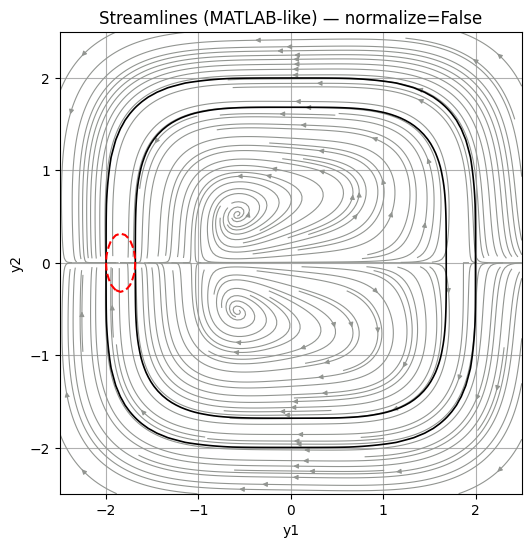

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
import math
import sys

# -------------------------
# User-tweakable parameters
# -------------------------
xrange = [-2.5, 2.5]      # match ranges you used in MATLAB
yrange = [-2.5, 2.5]
density_grid = 100        # number of points per axis (use same in MATLAB for matching)
numStart = 15             # number of start points per direction (MATLAB default was 15)
theta_stream = 0.0        # placeholder (not used by k1 if k1 only depends on (y0,y1))
v_stream = 0.85           # placeholder
normalize = False         # MATLAB did not normalize; set True only if you normalized in MATLAB
use_quiver_debug = False  # show quiver to debug orientation before streamlines
quiver_subsample = 8      # subsample for quiver to avoid clutter

# color that matches your MATLAB RGB
matlab_grey = (146/255, 149/255, 145/255)

# safe epsilon
_eps = 1e-12

# ------------------------------------------------
# Build grid (ensure shapes match MatLab convention)
# ------------------------------------------------
xs = np.linspace(xrange[0], xrange[1], density_grid)
ys = np.linspace(yrange[0], yrange[1], density_grid)
# Note: XX,YY shapes: (len(ys), len(xs)) — rows correspond to y, cols correspond to x
XX, YY = np.meshgrid(xs, ys)   # indexing='xy' default
ZZ = np.zeros_like(XX)
PH = np.zeros_like(XX)
for ii in range(XX.shape[0]):
    for jj in range(XX.shape[1]):
        ZZ[ii,jj] = float(psi_func_numpy(XX[ii,jj], YY[ii,jj]))
        PH[ii,jj] = float(phi_func_numpy(XX[ii,jj], YY[ii,jj]))

# initialize U,V with shape (len(ys), len(xs))
U = np.zeros_like(XX, dtype=float)
V = np.zeros_like(XX, dtype=float)

# ------------------------------------------------
# Try batch evaluation using CasADi (fast). If fails, fall back to loops.
# ------------------------------------------------
# Helper to introspect k1_fun input size (CasADi)
try:
    # number of rows expected by k1_fun input
    # note: k1_fun.size_in(0) gives (nrows, ncols) shape of input (CasADi >=3.5+)
    shape_in = k1_fun.size_in(0)  # returns tuple (nrows, ncols) for a MX/DM input
    # shape_in may be (n,1) for column vector input
except Exception:
    # Fallback: try evaluating once with a 2-vector to see accepted shape
    shape_in = None

# Flattened grid point count
N = XX.size

# Build candidate batched input depending on expectation:
# - If k1_fun expects a 2x1 or 4x1 input, we will provide an (n x N) DM where n is rows.
#   If k1_fun expects 4 rows (y0,y1,theta,v), fill theta and v with chosen constants.
# We'll try both 2-row and 4-row batch calls, catching exceptions.

def try_batch_eval(num_rows):
    """
    Attempt to evaluate k1_fun on a batch of shape (num_rows, N).
    Returns (U_flat, V_flat) arrays if success, or raises.
    """
    if num_rows == 2:
        # 2 rows: y0, y1
        X_batch = np.vstack([XX.ravel(), YY.ravel()])   # shape (2, N)
    elif num_rows == 4:
        X_batch = np.vstack([XX.ravel(), YY.ravel(),
                             theta_stream * np.ones(N),
                             v_stream * np.ones(N)])        # shape (4, N)
    else:
        raise RuntimeError("Unsupported num_rows proposal: %d" % num_rows)

    try:
        X_dm = ca.DM(X_batch)   # convert to CasADi DM for batch evaluation
        out = k1_fun(X_dm)      # call: may return DM or list
        # Extract DM if returned in list/dict-like
        if isinstance(out, (list, tuple)):
            k_dm = out[0]
        elif isinstance(out, dict):
            # sometimes CasADi functions with named outputs return a dict
            k_dm = next(iter(out.values()))
        else:
            k_dm = out
        k_numpy = np.array(k_dm)  # shape expected (2, N) or (m, N)
        # If shape is (2,N) or (N,2) handle accordingly:
        if k_numpy.shape[0] == 2 and k_numpy.ndim == 2:
            U_flat = k_numpy[0, :].astype(float)
            V_flat = k_numpy[1, :].astype(float)
        elif k_numpy.shape[1] == 2 and k_numpy.ndim == 2:
            # sometimes output is (N,2)
            U_flat = k_numpy[:, 0].astype(float)
            V_flat = k_numpy[:, 1].astype(float)
        else:
            # attempt flatten and take first two components per column
            # reshape to (n_outputs, N)
            k_numpy_flat = k_numpy.reshape((-1, N))
            U_flat = k_numpy_flat[0, :].astype(float)
            V_flat = k_numpy_flat[1, :].astype(float)

        return U_flat, V_flat
    except Exception as e:
        raise

# Try options in this order: 2-row, 4-row (common for (y0,y1) or (y0,y1,theta,v))
batch_success = False
for rows_try in (2, 4):
    try:
        U_flat, V_flat = try_batch_eval(rows_try)
        # reshape back to grid shape (len(ys), len(xs))
        U = U_flat.reshape(XX.shape)
        V = V_flat.reshape(XX.shape)
        batch_success = True
        # print debug info
        print(f"Batch evaluation succeeded with {rows_try} rows input.")
        break
    except Exception as e:
        #print(f"Batch attempt with {rows_try} rows failed: {e}")
        continue

# If batch failed, fallback to double loop (robust)
if not batch_success:
    print("Batch evaluation failed: falling back to double loop evaluation (slower).", file=sys.stderr)
    for i in range(XX.shape[0]):      # rows -> y
        for j in range(XX.shape[1]):  # cols -> x
            # Build single column input for k1_fun
            # Try to call with 2-length first then 4-length if needed
            x2 = np.array([XX[i,j], YY[i,j]])
            x4 = np.array([XX[i,j], YY[i,j], theta_stream, v_stream])
            assigned = False
            for x_try in (x2, x4):
                try:
                    out = k_full_fun(x_try)
                    if isinstance(out, (list, tuple)):
                        out0 = out[0]
                    else:
                        out0 = out
                    out_arr = np.array(out0).flatten()
                    U[i,j] = float(out_arr[0])
                    V[i,j] = float(out_arr[1])
                    assigned = True
                    break
                except Exception:
                    continue
            if not assigned:
                # on failure set zero (like you did): but log if many failures happen
                U[i,j] = 0.0
                V[i,j] = 0.0

# ------------------------------------------------
# Optional normalization to match matlab decision
# ------------------------------------------------
if normalize:
    mag = np.sqrt(U**2 + V**2)
    mag[mag < _eps] = 1.0
    U_plot = U / mag
    V_plot = V / mag
else:
    U_plot = U
    V_plot = V

# ------------------------------------------------
# Create start points to match MATLAB startx/starty
# ------------------------------------------------
startx = np.linspace(xrange[0] * 0.9, xrange[1] * 0.9, numStart)
starty = np.linspace(yrange[0] * 0.9, yrange[1] * 0.9, numStart)
sx, sy = np.meshgrid(startx, starty)
start_pts = np.vstack((sx.ravel(), sy.ravel())).T   # shape (Nstart, 2)

# ------------------------------------------------
# Debug quiver (optional) to verify vector orientation
# ------------------------------------------------
if use_quiver_debug:
    plt.figure(figsize=(7,6))
    # Subsample for quiver to avoid overcrowding
    s = quiver_subsample
    plt.quiver(xs[::s], ys[::s],
               U_plot[::s, ::s].T, V_plot[::s, ::s].T,
               angles='xy', scale_units='xy', scale=1.0)
    plt.title('quiver debug (check orientation)')
    plt.axis('equal'); plt.xlim(xrange); plt.ylim(yrange); plt.grid(True)
    plt.show()

# ------------------------------------------------
# Plot streamlines: pass U_plot, V_plot with same shapes as (len(ys), len(xs))
# Note: when you supply explicit start_points, set density=1 so automatic seeding is minimal
# ------------------------------------------------
plt.figure(figsize=(8,6))
plt.streamplot(xs, ys, U_plot, V_plot,
               start_points=start_pts,
               density=4.0,
               color=matlab_grey,
               linewidth=0.8,
               arrowsize=0.7)



# Optionally overlay contours of psi/phi if you have them on same grid
# try: contour with XX, YY or XXs, YYs that match the range
plt.contour(XX, YY, ZZ, levels=[0.0], colors='k', linewidths=1.2)
plt.contour(XX, YY, PH, levels=[0.0], colors='r', linestyles='--')

plt.title(f"Streamlines (MATLAB-like) — normalize={normalize}")
plt.xlabel('y1')   # match your MATLAB labels
plt.ylabel('y2')
plt.xlim(xrange)
plt.ylim(yrange)
plt.gca().set_box_aspect(1.0)  # keep axes equal-ish
plt.grid(True)
plt.show()


In [58]:

# Also create Psi_cas expression (terminal certificate)
diff_cas = Lfh_cas - k1_at_x_cas
Psi_cas = psi_cas - (1.0 / (2.0 * MU_1)) * ca.dot(diff_cas, diff_cas)
Psi_fun_cas = ca.Function('Psi_fun', [x_c], [Psi_cas], ['x'], ['Psi'])


# -------------------------
# discrete dynamics CasADi function f_disc(x,u) = x + DT*(f(x) + g*u)
# -------------------------
f_cas = ca.SX.zeros(nx, 1)
f_cas[0] = x_c[3] * ca.cos(x_c[2])
f_cas[1] = x_c[3] * ca.sin(x_c[2])
f_cas[2] = 0
f_cas[3] = 0
g_cas = ca.SX.zeros(nx, nu)
g_cas[2, 0] = 1
g_cas[3, 1] = 1
# xnext_cas = x_c + DT * (f_cas + ca.mtimes(g_cas, u_c))
def casadi_rk4_step(x, u):
    DTc = DT
    f1 = ca.vertcat(x[3]*ca.cos(x[2]), x[3]*ca.sin(x[2]), u[0], u[1])
    x2 = x + 0.5*DTc * f1
    f2 = ca.vertcat(x2[3]*ca.cos(x2[2]), x2[3]*ca.sin(x2[2]), u[0], u[1])
    x3 = x + 0.5*DTc * f2
    f3 = ca.vertcat(x3[3]*ca.cos(x3[2]), x3[3]*ca.sin(x3[2]), u[0], u[1])
    x4 = x + DTc * f3
    f4 = ca.vertcat(x4[3]*ca.cos(x4[2]), x4[3]*ca.sin(x4[2]), u[0], u[1])
    return x + (DTc/6.0)*(f1 + 2*f2 + 2*f3 + f4)

xnext_cas = casadi_rk4_step(x_c, u_c)

f_disc = ca.Function('f_disc', [x_c, u_c], [xnext_cas], ['x', 'u'], ['xnext'])

# -------------------------
# Build one-time NMPC solver with the upgraded logic
# Decision vars: X (nx x N), U (nu x N)
# Constraints:
# - dynamics: X[:,k+1] = f_disc(X[:,k], U[:,k])
# - safety for each predicted state: psi(h(X[:,k])) >= 0  (hard)
# - terminal: Psi(X[:,N-1]) >= 0  (note indexing: X columns correspond to x1..xN)
# Objective:
# sum_k [ ||y_k - GOAL||^2 * Qy + R_u ||U_k||^2 + ALPHA * ||U_k - k_full(X_k)||^2 ]
# -------------------------
def build_mpc_solver(N):
    X = ca.SX.sym('X', nx, N)   # predicted x1..xN
    U = ca.SX.sym('U', nu, N)   # u0..u_{N-1}
    P = ca.SX.sym('P', nx)      # parameter current state x0

    opt_vars = ca.vertcat(ca.reshape(X, -1, 1), ca.reshape(U, -1, 1))

    g_list = []
    obj = ca.SX(0)

    for k in range(N):
        # define xk (the state used for computing U_k)
        if k == 0:
            xk = P  # current state as parameter
        else:
            xk = X[:, k-1]   # predicted state x_k

        uk = U[:, k]

        # predict next state equality: X[:, k] == f_disc(xk, uk)
        xkpred = f_disc(xk, uk)
        g_list.append(X[:, k] - xkpred)

        # stage cost
        y_k = X[0:2, k]  # predicted output at stage k (x1,x2)
        # tracking
        obj = obj + Qy * ca.dot(y_k - ca.DM(GOAL), y_k - ca.DM(GOAL))
        # control effort
        obj = obj + R_u * ca.dot(uk, uk)

        # bias toward backstepping controller at stage k:
        # build k_full evaluated at xk (use k_full_cas, but substitute x_c -> xk)
        k_full_at_xk = ca.substitute([k_full_cas], [x_c], [xk])[0]
        diff_u = uk - k_full_at_xk
        obj = obj + ALPHA * ca.dot(diff_u, diff_u)

        # safety constraint for predicted state X[:,k]
        # evaluate psi at (X[0,k], X[1,k])
        psi_at_stage = ca.substitute([psi_cas], [y_c[0], y_c[1]], [X[0, k], X[1, k]])[0]
        # enforce psi_at_stage >= 0 (we will set lbg accordingly)
        g_list.append(psi_at_stage)  # inequality entry; we'll set lbg/ubg later

    # Terminal constraint: Psi(X[:,N-1]) >= 0
    xN = X[:, N-1]
    Psi_at_end = ca.substitute([Psi_cas], [x_c], [xN])[0]
    g_list.append(Psi_at_end)

    # stack constraints
    g_all = ca.vertcat(*g_list)

    nlp = {'x': opt_vars, 'f': obj, 'g': g_all, 'p': P}
    opts = {
        'ipopt': {
            'print_level': 0,
            'max_cpu_time': IPOPT_MAX_CPU,
            'tol': IPOPT_TOL,
            'acceptable_tol': 1e-4,
        },
        'print_time': False
    }
    # create solver
    solver = ca.nlpsol('solver', 'ipopt', nlp, opts)

    nxN = nx * N
    nconstr = int(g_all.numel())
    return solver, nxN, nconstr

solver, nxN, nconstr = build_mpc_solver(HORIZON)

# -------------------------
# Default bounds & initial guesses (structured)
# -------------------------
def default_bounds_and_guesses(N):
    nxN = nx * N
    nuN = nu * N
    nvars = nxN + nuN
    x0_guess = np.zeros(nvars)
    lbx = -1e20 * np.ones(nvars)
    ubx =  1e20 * np.ones(nvars)
    # set U bounds
    for k in range(N):
        idx = nxN + k*nu
        lbx[idx:idx+nu] = U_MIN
        ubx[idx:idx+nu] = U_MAX
    # constraints: we have for each k two equality vector components (dynamics) + one psi inequality per stage + final Psi
    # It's easier to set lbg/ubg per stacked g_list: For equality dynamics entries -> 0==0; for psi entries -> >=0; final Psi >=0
    # We'll compose lbg/ubg during solve because number of eq/ineq alternates.
    # But we return generic arrays for now:
    # We'll construct lbg/ubg in solve_mpc_once to match ordering.
    return x0_guess, lbx, ubx

x0_guess_template, lbx, ubx = default_bounds_and_guesses(HORIZON)

# -------------------------
# Warm-start storage and helper to build consistent initial guess
# -------------------------
_prev_w_opt = None  # keep global
use_warmstart = False

def make_initial_guess(x0, N, prev_w_opt=None, use_warmstart=False):
    nxN = nx * N
    nuN = nu * N
    nvars = nxN + nuN
    if use_warmstart and prev_w_opt is not None and prev_w_opt.size == nvars:
        return prev_w_opt.copy()
    # else create structured guess: predicted X all equal to x0, U zeros
    guess = np.zeros(nvars)
    for k in range(N):
        idx = k * nx
        guess[idx:idx+nx] = x0
    return guess


# -------------------------
# solve_mpc_once: build appropriate lbg/ubg, call solver with warm-start, return u0 and diagnostic info
# -------------------------
def solve_mpc_once(x0, N=HORIZON):
    global _prev_w_opt
    p = x0.copy()
    # build initial guess
    x0_guess_local = make_initial_guess(x0, N, _prev_w_opt, use_warmstart)
    # compose lbg, ubg consistent with g_list ordering in build_mpc_solver
    # For each k we appended: [ dynamics (nx eq) ; psi_at_stage (ineq) ] repeated N times, and final Psi (ineq)
    # So total constraints = N*(nx + 1) + 1(final) ; but final was appended as last, so total = N* (nx+1) + 1? Let's re-derive:
    # In build loop per k: g_list.append(X[:,k] - xkpred) --> vector of size nx (equality)
    # then g_list.append(psi_at_stage) --> scalar (inequality)
    # after loop: g_list.append(Psi_at_end) --> scalar (inequality)
    # So stacked g_all has length N*nx + N*1 + 1 = N*nx + N + 1
    total_eq = N * nx
    total_ineq_stage = N
    total_ineq_final = 1
    total_constraints = total_eq + total_ineq_stage + total_ineq_final
    # Build lbg/ubg arrays
    lbg = np.zeros(total_constraints)
    ubg = np.zeros(total_constraints)
    # For equality blocks (dynamics) indices [0 : N*nx) -> lbg=0, ubg=0
    # For stage psi inequalities, they are located after each dynamics block; their indices are:
    # idx = k*(nx + 1) + nx   (if we think in groups). Simpler: we can fill by iterating
    # But easiest is to construct by following the same ordering:
    idx = 0
    for k in range(N):
        # dynamics nx entries
        idx += nx
        # psi inequality scalar
        # set lbg[idx] = 0, ubg[idx] = +inf
        lbg[idx] = 0.0
        ubg[idx] = 1e20
        idx += 1
    # final Psi (last constraint)
    # idx now equals N*nx + N
    lbg[idx] = 0.0
    ubg[idx] = 1e20

    try:
        tic = time.time()
        sol = solver(x0=x0_guess_local, lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg, p=p)
        elapsed = time.time() - tic
        w_opt = np.array(sol['x']).flatten()
        _prev_w_opt = w_opt.copy()  # warm-start next time
        u0 = w_opt[nxN : nxN + nu].copy()
        # extract X_N for diagnostics
        X_flat = w_opt[0 : nxN]
        xN = X_flat[(N-1)*nx : N*nx].copy()
        # compute diagnostics
        psi_pred_vals = []
        # compute min predicted psi across stages (numeric) for logging
        for k in range(N):
            xk_pred = X_flat[k*nx : (k+1)*nx]
            psi_k = float(sp.N(psi_sym.subs({y0_s: xk_pred[0], y1_s: xk_pred[1]})))
            psi_pred_vals.append(psi_k)
        min_psi_pred = float(np.min(psi_pred_vals))
        psi_terminal = float(sp.N(Psi_cas(xN).full()[0,0])) if False else compute_Psi_numeric_from_numpy(xN)  # fallback numeric
        # objective value
        obj_val = float(sol['f'])
        stats = solver.stats()
        return True, u0, {'xN': xN, 'min_psi_pred': min_psi_pred, 'psi_terminal': psi_terminal, 'obj': obj_val, 'solve_time': elapsed, 'stats': stats}
    except Exception as e:
        return False, None, {'error': str(e)}

# -------------------------
# Numeric helper to evaluate Psi using numpy (for logging)
# We build numeric k1 and derivatives lambdified earlier to compute Psi quickly.
# Use existing lambdify functions to compute psi, k1, etc.
# -------------------------
# Create lambdified numeric functions for k1 and its derivatives (used in compute_Psi_numeric_from_numpy)
k1_func_numpy = sp.lambdify((y0_s, y1_s), sp.Matrix([k1_0_sym, k1_1_sym]), 'numpy')
dk1_dy00 = sp.diff(k1_0_sym, y0_s)
dk1_dy01 = sp.diff(k1_0_sym, y1_s)
dk1_dy10 = sp.diff(k1_1_sym, y0_s)
dk1_dy11 = sp.diff(k1_1_sym, y1_s)
dk1_funcs_np = (
    sp.lambdify((y0_s, y1_s), dk1_dy00, 'numpy'),
    sp.lambdify((y0_s, y1_s), dk1_dy01, 'numpy'),
    sp.lambdify((y0_s, y1_s), dk1_dy10, 'numpy'),
    sp.lambdify((y0_s, y1_s), dk1_dy11, 'numpy'),
)

def eval_k1_numpy(y):
    return np.array(k1_func_numpy(y[0], y[1]), dtype=float).reshape((2,))

def compute_Lfh_numpy(x):
    theta = x[2]; v = x[3]
    return np.array([v * math.cos(theta), v * math.sin(theta)], dtype=float)

def compute_Psi_numeric_from_numpy(x):
    # psi(y)
    y = np.array([x[0], x[1]], dtype=float)
    psi_val = float(psi_func_numpy(y[0], y[1]))
    Lfh = compute_Lfh_numpy(x)
    k1_val = eval_k1_numpy(y)
    diff = Lfh - k1_val
    val = psi_val - (1.0 / (2.0 * MU_1)) * float(np.dot(diff, diff))
    return float(val)

# -------------------------
# Plant integrator RK4 (for simulation)
# -------------------------
def rk4_step(xvec, uvec, dt=DT):
    def f_cont(xv, uv):
        return np.array([xv[3]*math.cos(xv[2]), xv[3]*math.sin(xv[2]), uv[0], uv[1]])
    k1 = f_cont(xvec, uvec)
    k2 = f_cont(xvec + 0.5*dt*k1, uvec)
    k3 = f_cont(xvec + 0.5*dt*k2, uvec)
    k4 = f_cont(xvec + dt*k3, uvec)
    return xvec + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# -------------------------
# run closed-loop simulation using MPC-only (no fallback to k(x))
# At each step, solve MPC; if infeasible, the function returns failure (we will log and break).
# -------------------------
def run_mpc_closed_loop(initial_state, horizon=HORIZON, max_steps=300, log_file=None):
    x = initial_state.copy()
    traj = [x.copy()]
    used = []
    reached = False

    # prepare CSV log
    if log_file is not None:
        csv_f = open(log_file, 'w', newline='')
        csv_writer = csv.writer(csv_f)
        csv_writer.writerow(['step','used','psi_current','min_psi_pred','psi_terminal','obj','solve_time','reached','note'])
    else:
        csv_f = None
        csv_writer = None

    for t in range(max_steps):
        psi_curr = float(psi_func_numpy(x[0], x[1]))
        ok, u0, info = solve_mpc_once(x, N=horizon)
        
        if not ok:
            # infeasible or solver failure -> log and break (no fallback per user request)
            note = f"MPC infeasible or failed at step {t}: {info.get('error')}"
            print(note)
            if csv_writer:
                csv_writer.writerow([t, 'MPC_FAIL', psi_curr, None, None, None, None, False, note])
            break

        # we have a solution accepted; apply u0
        u_apply = np.minimum(np.maximum(np.array(u0).reshape((2,)), U_MIN), U_MAX)
        used.append('MPC')
        # logging info extraction
        min_psi_pred = info.get('min_psi_pred', None)
        psi_terminal = info.get('psi_terminal', None)
        obj_val = info.get('obj', None)
        solve_time = info.get('solve_time', None)

        # apply to plant
        x = rk4_step(x, u_apply, DT)
        traj.append(x.copy())
        
        # check target
        phi_val = float(phi_func_numpy(x[0], x[1]))
        reached = True if (phi_val < 0) else False

        # log
        if csv_writer:
            csv_writer.writerow([t, 'MPC', psi_curr, min_psi_pred, psi_terminal, obj_val, solve_time, reached, ''])
        else:
            print(f"step {t}: psi_curr={psi_curr:.4e}, min_psi_pred={min_psi_pred:.4e}, psi_term={psi_terminal:.4e}, obj={obj_val:.6f}, solved_in={solve_time:.3f}s")

        if reached:
            print(f"Reached target at step {t}")
            break

    if csv_f:
        csv_f.close()

    return {'traj': np.array(traj), 'used': used, 'reached': reached}


x: [1.85       0.8        1.57079633 0.85      ] psi= 15.984844851210937  Psi= 7.815182887985079
Running upgraded MPC-only closed-loop (no fallback). Logging to mpc_upgraded_log.csv

Trial 0, initial = [1.85       0.8        1.57079633 0.85      ]
Reached target at step 53
Result: reached steps: 55


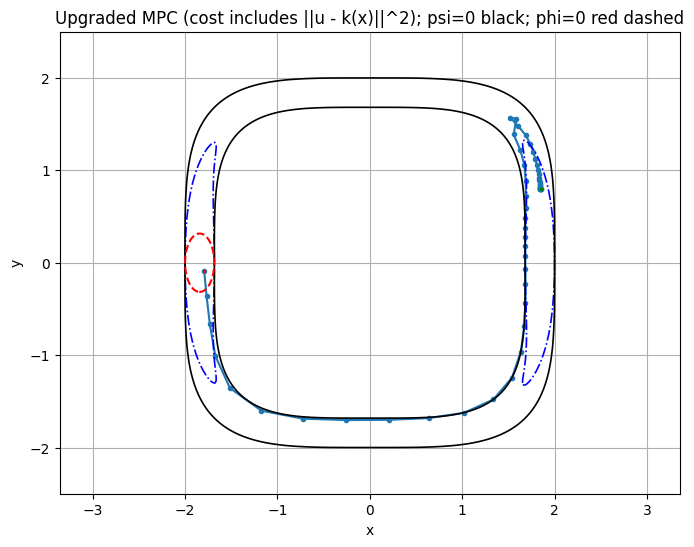

In [59]:

# -------------------------
# Example usage: explicit initials
# -------------------------
if __name__ == "__main__":
    initials = [
        # np.array([-1.5, 1.7, -3*math.pi/4, 0.2]),
        np.array([1.85,  0.8, math.pi/2, 0.85])
        # np.array([-1.5, -1.6, math.pi/2, 0.25])
    ]
    for x in initials:
        psi_v = float(psi_func_numpy(x[0], x[1]))
        Psi_v = compute_Psi_numeric_from_numpy(x)   # you already have this helper
        print("x:", x, "psi=", psi_v, " Psi=", Psi_v)    

    print("Running upgraded MPC-only closed-loop (no fallback). Logging to", LOG_CSV)
    all_results = []
    for i, init in enumerate(initials):
        print(f"\nTrial {i}, initial = {init}")
        res = run_mpc_closed_loop(init, horizon=HORIZON, max_steps=2000, log_file=f"run_{i}_" + LOG_CSV)
        all_results.append(res)
        print("Result:", "reached" if res['reached'] else "not reached", "steps:", res['traj'].shape[0])

    # plot trajectories
    plt.figure(figsize=(8,6))
    for r in all_results:
        tr = r['traj']
        plt.plot(tr[:,0], tr[:,1], '-o', markersize=3)
        # start point
        plt.plot(tr[0,0], tr[0,1],
                marker='s', markersize=2,
                color='green', label=None)

        # end point
        plt.plot(tr[-1,0], tr[-1,1],
                marker='*', markersize=2,
                color='red', label=None)        
    # plot psi=0 and phi=0 contours
    xs = np.linspace(-2.5, 2.5, 250)
    ys = np.linspace(-2.5, 2.5, 250)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.zeros_like(XX)
    PH = np.zeros_like(XX)
    PH_new = np.zeros_like(XX)
    for ii in range(XX.shape[0]):
        for jj in range(XX.shape[1]):
            ZZ[ii,jj] = float(psi_func_numpy(XX[ii,jj], YY[ii,jj]))
            PH[ii,jj] = float(phi_func_numpy(XX[ii,jj], YY[ii,jj]))

    Psi_vals = np.zeros_like(XX)

    for ii in range(XX.shape[0]):
        x_batch = XX[ii, :]
        y_batch = YY[ii, :]

        # Build full 4×N state input
        full_state = np.vstack([
            x_batch,                # x0
            y_batch,                # x1
            np.zeros_like(x_batch), # theta = 0
            np.zeros_like(x_batch)  # v = 0
        ])

        Psi_vals[ii, :] = np.array(Psi_fun_cas(full_state)).flatten()

    plt.contour(XX, YY, Psi_vals, levels=[0.0], colors='blue', linestyles='-.', linewidths=1.2)                                 
    plt.contour(XX, YY, ZZ, levels=[0.0], colors='k', linewidths=1.2)
    plt.contour(XX, YY, PH, levels=[0.0], colors='r', linestyles='--')
    plt.title("Upgraded MPC (cost includes ||u - k(x)||^2); psi=0 black; phi=0 red dashed")
    plt.xlabel('x'); plt.ylabel('y'); plt.axis('equal'); plt.grid(True)
    plt.show()
